# Analisis de huelgas 1993-2024

Este notebook lee la base maestra homologada, resume cobertura, grafica cruces posibles y verifica la consistencia del modulo de calificacion contra la fuente.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / 'bases').exists() and (ROOT / 'notebooks').exists():
    project_root = ROOT
else:
    project_root = ROOT.parent
BASE = project_root / 'bases' / 'maestra'
GRAPH = BASE / 'graficos'

master = pd.read_csv(BASE / 'huelgas_modulos_maestra_1993_2024.csv')
coverage = pd.read_csv(BASE / 'cobertura_modulos_1993_2024.csv')
legalidad = pd.read_csv(BASE / 'huelgas_legalidad_1996_2024_largo.csv')
legalidad_resumen = pd.read_csv(BASE / 'huelgas_legalidad_1996_2024_resumen_anual.csv')
verif = pd.read_csv(BASE / 'verificacion_calificacion_1993_2024_largo.csv')
verif_resumen = pd.read_csv(BASE / 'verificacion_calificacion_1993_2024_resumen.csv')
anio_sector = pd.read_csv(BASE / 'cruce_anio_sector_largo.csv')
anio_territorio = pd.read_csv(BASE / 'cruce_anio_territorio_regional_largo.csv')


## Cobertura y estructura

La auditoria global y la cobertura por modulo ya vienen consolidadas en la carpeta `bases/maestra`.


In [2]:
coverage.head(15)


,anio,archivo_homologado,carpeta_bloque,tipo_anio,modulo,filas_modulo,modulo_con_datos,estados_validacion,modulo_no_disponible_fuente
0,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,actividad,0,0,no_disponible,1
1,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,calificacion,0,0,no_disponible,1
2,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,causas,0,0,no_disponible,1
3,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,duracion,0,0,no_disponible,1
4,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,organizacion,0,0,no_disponible,1
5,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,tamano,0,0,no_disponible,1
6,1993,huelgas_1993_homologado.xlsx,era1_homologados,excluido_sin_excel_fuente,territorio,0,0,no_disponible,1
7,1994,huelgas_1994_homologado.xlsx,era1_homologados,parcial,actividad,9,1,ok,0
8,1994,huelgas_1994_homologado.xlsx,era1_homologados,parcial,calificacion,0,0,no_disponible,1
9,1994,huelgas_1994_homologado.xlsx,era1_homologados,parcial,causas,2,1,ok,0


## Legalidad por año

Este es el cruce observable directamente con la fuente. No existe un cruce directo `legalidad x sector` ni `legalidad x territorio` en los anuarios usados para la base principal.


In [3]:
legalidad_resumen.head()


,anio,huelgas_ilegal,huelgas_procedente,trabajadores_comprendidos_ilegal,trabajadores_comprendidos_procedente,horas_hombre_perdidas_ilegal,horas_hombre_perdidas_procedente,huelgas_total_observado,trabajadores_comprendidos_total_observado,horas_hombre_perdidas_total_observado
0,1996,70.0,7.0,34211.0,2031.0,942174.0,457712.0,77.0,36242.0,1399886.0
1,1997,65.0,1.0,19076.0,120.0,316534.0,2880.0,66.0,19196.0,319414.0
2,1998,55.0,3.0,16986.0,347.0,296740.0,26428.0,58.0,17333.0,323168.0
3,1999,69.0,2.0,51243.0,837.0,710492.0,13768.0,71.0,52080.0,724260.0
4,2000,36.0,1.0,5272.0,8.0,180091.0,1600.0,37.0,5280.0,181691.0


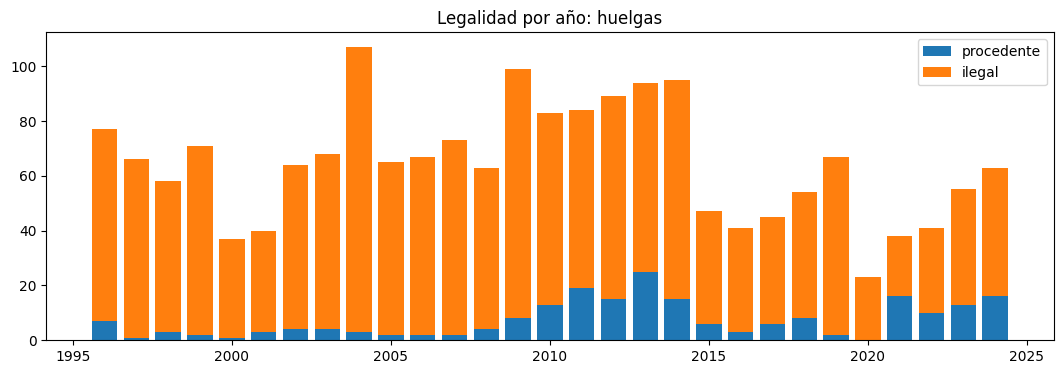

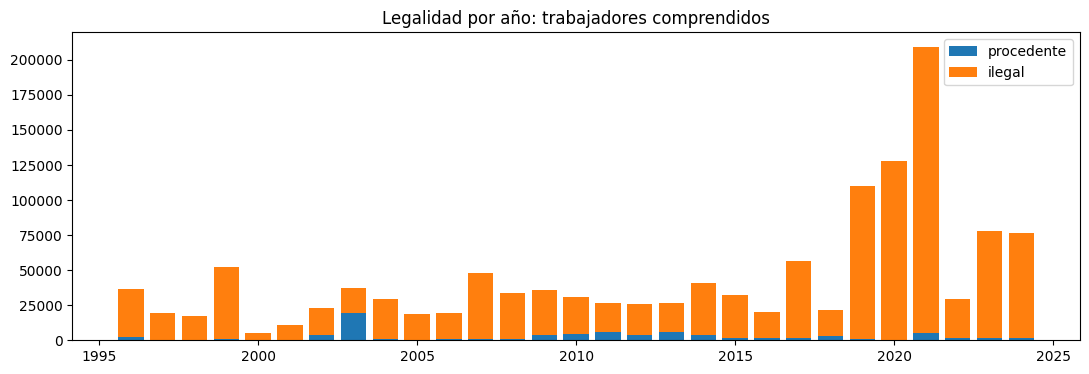

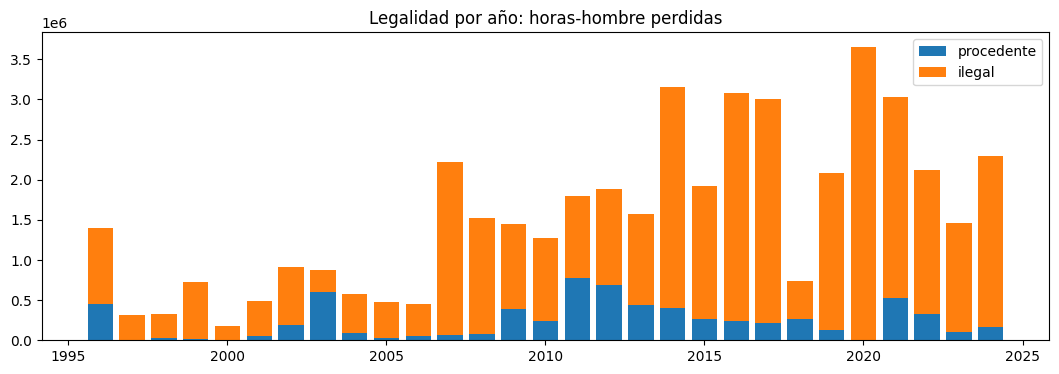

In [4]:
for metric, title in [
    ('huelgas', 'Legalidad por año: huelgas'),
    ('trabajadores_comprendidos', 'Legalidad por año: trabajadores comprendidos'),
    ('horas_hombre_perdidas', 'Legalidad por año: horas-hombre perdidas'),
]:
    proc = f'{metric}_procedente'
    ilegal = f'{metric}_ilegal'
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(legalidad_resumen['anio'], legalidad_resumen[proc], label='procedente')
    ax.bar(legalidad_resumen['anio'], legalidad_resumen[ilegal], bottom=legalidad_resumen[proc], label='ilegal')
    ax.set_title(title)
    ax.legend()
    plt.show()


## Cruce año x sector


In [5]:
pivot_sector = pd.read_csv(BASE / 'cruce_anio_sector_huelgas_pivot.csv').set_index('anio')
pivot_sector.head()


,adm_publica,agricultura,comercio,construccion,electricidad_agua,ensenanza,explotacion_de_petroleo_y_gas_natural,financiero,inmobiliario,manufactura,mineria,otros_servicios,paro_nacional,pesca,salud_social,transporte
anio,,,,,,,,,,,,,,,,
1994,0.0,2.0,0.0,0.0,21.0,0.0,0.0,1.0,0.0,65.0,35.0,0.0,0.0,5.0,10.0,29.0
1995,0.0,0.0,1.0,12.0,7.0,3.0,0.0,0.0,1.0,28.0,37.0,0.0,0.0,0.0,5.0,8.0
1996,0.0,0.0,0.0,21.0,1.0,0.0,9.0,0.0,0.0,10.0,17.0,0.0,0.0,5.0,4.0,10.0
1997,0.0,1.0,0.0,22.0,3.0,0.0,0.0,0.0,1.0,14.0,7.0,0.0,0.0,0.0,3.0,15.0
1998,0.0,0.0,1.0,14.0,2.0,0.0,0.0,0.0,1.0,15.0,12.0,0.0,0.0,0.0,0.0,13.0


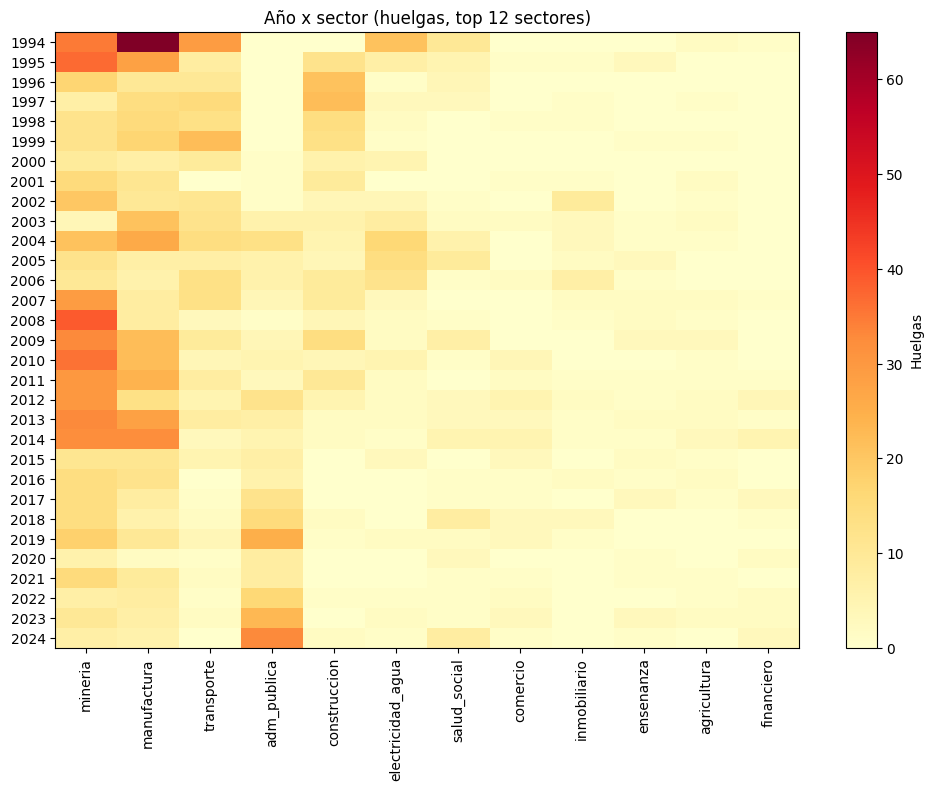

In [6]:
heat = pivot_sector.copy()
top_cols = heat.sum(axis=0).sort_values(ascending=False).head(12).index
heat = heat[top_cols]
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index.astype(str))
ax.set_title('Año x sector (huelgas, top 12 sectores)')
fig.colorbar(im, ax=ax, label='Huelgas')
plt.show()


## Cruce año x territorio

Se usa solo `nivel_territorial = regional` para evitar duplicar con zonas.


In [7]:
pivot_territorio = pd.read_csv(BASE / 'cruce_anio_territorio_regional_huelgas_pivot.csv').set_index('anio')
pivot_territorio.head()


,ancash,andres_a_caceres,apurimac,arequipa,ayacucho,cajamarca,callao,chavin,cusco,grau,...,moquegua_tacna_puno,nor_oriental_del_maranon,otros,pasco,piura,puno,san_martin,tacna,tumbes,ucayali
anio,,,,,,,,,,,,,,,,,,,,,
1994,0.0,7.0,0.0,20.0,0.0,0.0,0.0,3.0,0.0,8.0,...,4.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1995,0.0,9.0,0.0,7.0,0.0,0.0,0.0,5.0,0.0,16.0,...,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,0.0,8.0,0.0,2.0,0.0,0.0,0.0,11.0,0.0,10.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,3.0,0.0,6.0,0.0,0.0,0.0,13.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,8.0,0.0,8.0,0.0,0.0,0.0,2.0,0.0,3.0,...,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


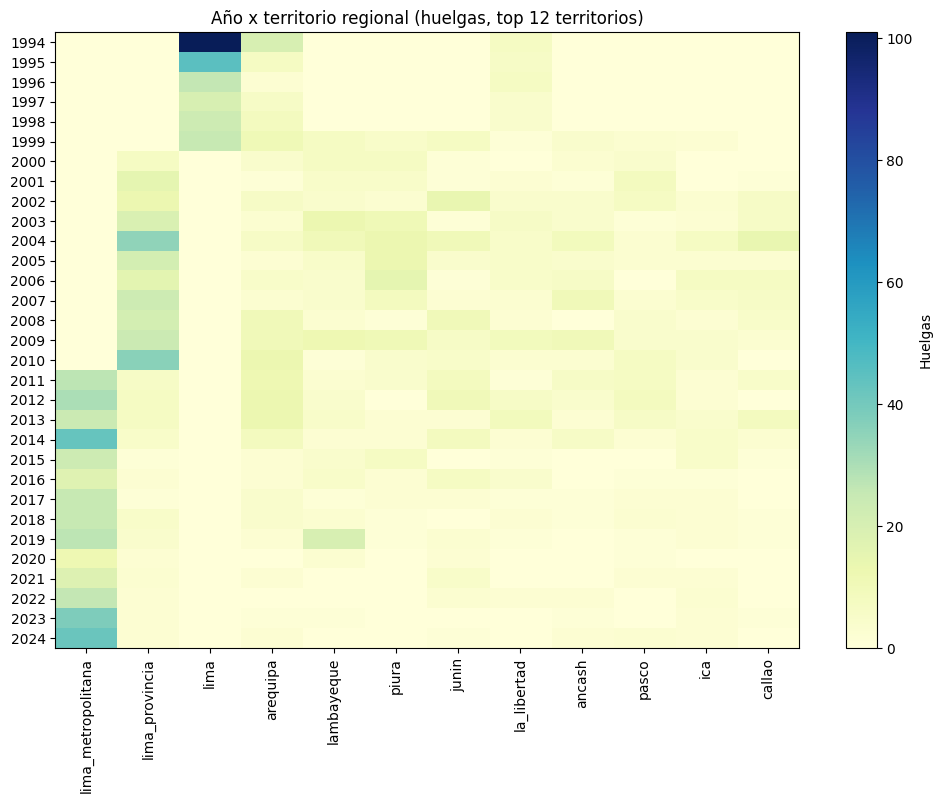

In [8]:
heat = pivot_territorio.copy()
top_cols = heat.sum(axis=0).sort_values(ascending=False).head(12).index
heat = heat[top_cols]
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index.astype(str))
ax.set_title('Año x territorio regional (huelgas, top 12 territorios)')
fig.colorbar(im, ax=ax, label='Huelgas')
plt.show()


## Sector x territorio

Ese cruce **no forma parte de la base maestra principal** porque requiere el cuadro cruzado `actividad x territorio` de la base complementaria. La nota metodologica consolidada esta en `bases/maestra/nota_sector_territorio.md`.


## Verificación del módulo de calificación

Aquí se comprueba, para cada año con módulo disponible, que `procedente + ilegal` coincide con el `TOTAL` de la hoja fuente en las tres métricas.


In [9]:
verif_resumen


,anio,archivo_homologado,carpeta_bloque,horas_hombre_perdidas,huelgas,trabajadores_comprendidos,resultado_general
0,1993,huelgas_1993_homologado.xlsx,era1_homologados,no_disponible,no_disponible,no_disponible,no_disponible
1,1994,huelgas_1994_homologado.xlsx,era1_homologados,no_disponible,no_disponible,no_disponible,no_disponible
2,1995,huelgas_1995_homologado.xlsx,era1_homologados,no_disponible,no_disponible,no_disponible,no_disponible
3,1996,huelgas_1996_homologado.xlsx,era2_homologados_1996_1999,ok,ok,ok,ok
4,1997,huelgas_1997_homologado.xlsx,era2_homologados_1996_1999,ok,ok,ok,ok
5,1998,huelgas_1998_homologado.xlsx,era2_homologados_1996_1999,ok,ok,ok,ok
6,1999,huelgas_1999_homologado.xlsx,era2_homologados_1996_1999,ok,ok,ok,ok
7,2000,huelgas_2000_homologado.xlsx,era2_homologados_2000_2003,ok,ok,ok,ok
8,2001,huelgas_2001_homologado.xlsx,era2_homologados_2000_2003,ok,ok,ok,ok
9,2002,huelgas_2002_homologado.xlsx,era2_homologados_2000_2003,ok,ok,ok,ok
